# 📊 Notebook 03: Análise de Gestão Escolar
## Análise de Desigualdades de Gênero na Educação Básica Brasileira

**Autora:** Sara - Mestra em Educação

### 📋 Objetivos deste notebook:
1. Analisar a distribuição de gênero entre gestores escolares
2. Identificar padrões de representação feminina na gestão
3. Comparar proporção de gestoras por rede e região
4. Verificar se existe "inversão de gênero" na gestão escolar

---

⚠️ **NOTA IMPORTANTE:** Os dados do Censo 2025 são **agregados por escola**, mostrando quantidades de gestores por gênero, não dados individuais.

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Adicionar diretório de scripts ao path
import sys
sys.path.append('../scripts')

# Importar configurações
from config import CORES, GRAPHICS_PATH, PROCESSED_DATA_PATH

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Bibliotecas importadas!")

✅ Configurações carregadas!
📁 Dados brutos: /home/sara/Censo25/data/
📁 Dados processados: /home/sara/Censo25/data/processed/
📁 Gráficos: /home/sara/Censo25/outputs/figures/
✅ Bibliotecas importadas!


## 1️⃣ Carregar Dados Processados

In [2]:
# Carregar dados
df = pd.read_csv(PROCESSED_DATA_PATH + 'escolas_analise.csv', encoding='utf-8')

print(f"✅ Dados carregados: {len(df):,} escolas")
print(f"\n📋 Colunas de gestão disponíveis:")
cols_gestao = [c for c in df.columns if 'GEST' in c]
for col in cols_gestao:
    print(f"   - {col}")

# Verificar escolas com gestores
escolas_com_gestor = df[(df['QT_GEST_BAS_FEM'] > 0) | (df['QT_GEST_BAS_MASC'] > 0)].copy()
print(f"\n📊 Escolas com gestores identificados: {len(escolas_com_gestor):,} ({len(escolas_com_gestor)/len(df)*100:.1f}%)")

✅ Dados carregados: 180,540 escolas

📋 Colunas de gestão disponíveis:
   - QT_GEST_BAS
   - QT_GEST_BAS_FEM
   - QT_GEST_BAS_MASC
   - QT_GEST_BAS_DIRETOR
   - QT_GEST_BAS_OUTRO
   - PORC_GESTORAS

📊 Escolas com gestores identificados: 180,540 (100.0%)


## 2️⃣ Panorama Nacional: Quem São as Gestoras?

### 📊 Pergunta Norteadora: **Quem são as gestoras?**
Mulheres dirigem escolas, mas em que proporção e em quais redes?

In [3]:
# Calcular totais nacionais de gestores
print("📊 Panorama Nacional - Gestores Escolares:")
print("=" * 50)

total_gestoras = df['QT_GEST_BAS_FEM'].sum()
total_gestores = df['QT_GEST_BAS_MASC'].sum()
total_gestores_geral = total_gestoras + total_gestores

print(f"\n👩‍💼 Gestoras: {total_gestoras:,.0f} ({total_gestoras/total_gestores_geral*100:.1f}%)")
print(f"👨‍💼 Gestores: {total_gestores:,.0f} ({total_gestores/total_gestores_geral*100:.1f}%)")
print(f"📊 Total de gestores(as): {total_gestores_geral:,.0f}")

print(f"\n🔍 DESCOBERTA CHAVE:")
if total_gestoras > total_gestores:
    pct = total_gestoras/total_gestores_geral*100
    print(f"   ✨ As MULHERES são maioria na gestão escolar brasileira!")
    print(f"   ✨ {pct:.1f}% dos gestores são mulheres")
else:
    pct = total_gestores/total_gestores_geral*100
    print(f"   Os homens são maioria na gestão escolar ({pct:.1}%)")

📊 Panorama Nacional - Gestores Escolares:

👩‍💼 Gestoras: 151,610 (79.5%)
👨‍💼 Gestores: 39,031 (20.5%)
📊 Total de gestores(as): 190,641

🔍 DESCOBERTA CHAVE:
   ✨ As MULHERES são maioria na gestão escolar brasileira!
   ✨ 79.5% dos gestores são mulheres


In [ ]:
# Gráfico de pizza - Gestores por gênero
fig, ax = plt.subplots(figsize=(10, 8))

sizes = [total_gestoras, total_gestores]
labels = [f'Gestoras\n{total_gestoras:,.0f}\n({total_gestoras/total_gestores_geral*100:.1f}%)',
         f'Gestores\n{total_gestores:,.0f}\n({total_gestores/total_gestores_geral*100:.1f}%)']
colors = [CORES['feminino'], CORES['masculino']]

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='', startangle=90,
                                   textprops={'fontsize': 13, 'fontweight': 'bold'})

ax.set_title('Distribuição de Gênero dos Gestores Escolares\nBrasil 2025',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '04_genero_gestores.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 04_genero_gestores.png")
plt.show()

print("\n📝 INTERPRETAÇÃO:")
print("=" * 60)
print("Diferentemente do que se observa em outros setores da economia,")
print("as mulheres são MAIORIA na gestão escolar brasileira.")
print("Isso sugere que a educação tem características específicas")
print("que favorecem a ascensão feminina a cargos de liderança.")

## 3️⃣ Gestoras por Rede de Ensino

In [5]:
# Calcular proporção de gestoras por rede
print("📊 Proporção de Gestoras por Rede de Ensino:")
print("=" * 50)

df_rede = df.groupby('TP_DEPENDENCIA')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_rede['Total'] = df_rede['QT_GEST_BAS_FEM'] + df_rede['QT_GEST_BAS_MASC']
df_rede['% Gestoras'] = (df_rede['QT_GEST_BAS_FEM'] / df_rede['Total']) * 100
df_rede = df_rede.sort_values('% Gestoras', ascending=False)

print(df_rede[['Total', '% Gestoras']].to_string())

print("\n🔍 Insights:")
for rede in df_rede.index:
    pct = df_rede.loc[rede, '% Gestoras']
    print(f"   • {rede}: {pct:.1f}% gestoras")

📊 Proporção de Gestoras por Rede de Ensino:
                 Total  % Gestoras
TP_DEPENDENCIA                    
Privada          44315   83.870021
Municipal       113963   82.051192
Estadual         31609   65.604733
Federal            754   26.259947

🔍 Insights:
   • Privada: 83.9% gestoras
   • Municipal: 82.1% gestoras
   • Estadual: 65.6% gestoras
   • Federal: 26.3% gestoras


## 🔍 Reflexão Crítica sobre "Teto de Vidro"

Embora as mulheres sejam maioria na gestão escolar (79.5%), é importante analisar com mais nuance:

```python
print("\n🔍 ANÁLISE CRÍTICA:")
print("=" * 60)
print("Embora as mulheres sejam maioria na gestão escolar (79.5%),")
print("é importante notar que:")
print("  • Na rede FEDERAL, apenas {:.1f}% são gestoras".format(df_rede.loc['Federal', '% Gestoras']))
print("  • Isso sugere que o 'teto de vidro' pode existir em")
print("    contextos de maior prestígio e remuneração")
print("  • A feminização da gestão pode refletir a feminização")
print("    da própria profissão docente (aprox. 80% são mulheres)")
print("\n💡 Perguntas para investigação futura:")
print("  • Gestoras têm os mesmos salários que gestores?")
print("  • Escolas maiores/melhores têm mais gestoras ou gestores?")
print("  • Há segmentação por tipo de cargo (diretor vs vice-diretor)?")
```

💾 Gráfico salvo: 05_gestoras_por_rede.png


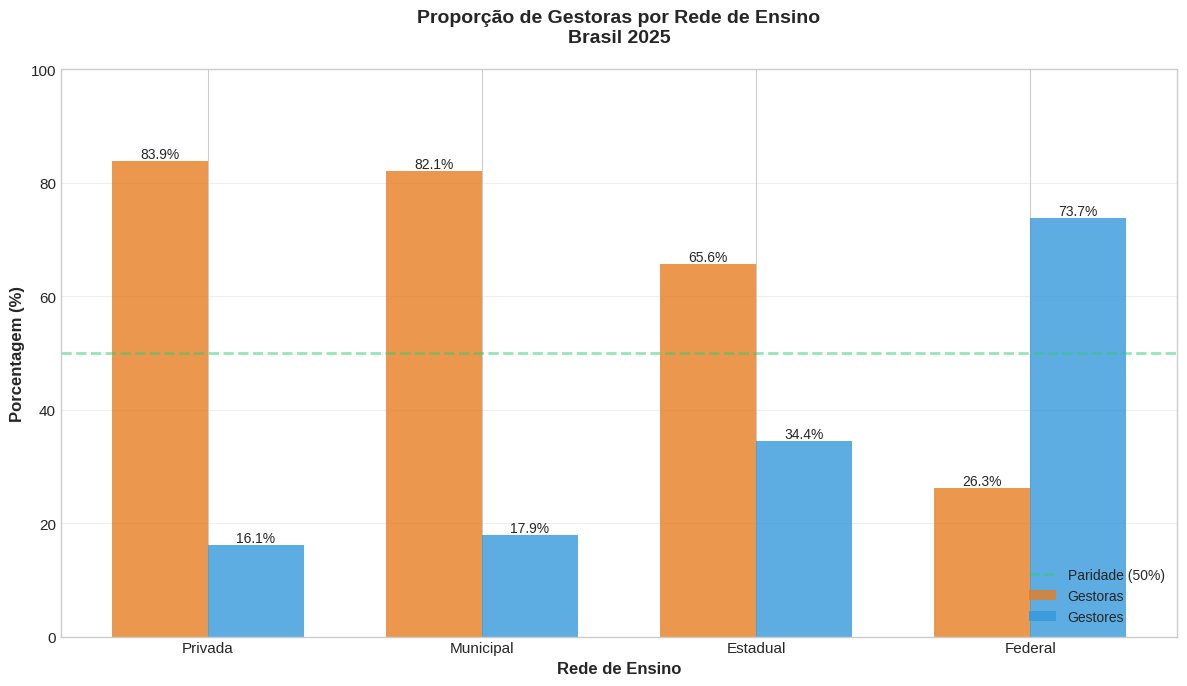

In [6]:
# Gráfico por rede
fig, ax = plt.subplots(figsize=(12, 7))

redes = df_rede.index.tolist()
x = np.arange(len(redes))
width = 0.35

bars1 = ax.bar(x - width/2, df_rede['% Gestoras'], width, label='Gestoras',
               color=CORES['feminino'], alpha=0.8)
bars2 = ax.bar(x + width/2, 100 - df_rede['% Gestoras'], width, label='Gestores',
               color=CORES['masculino'], alpha=0.8)

ax.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5, label='Paridade (50%)')

ax.set_xlabel('Rede de Ensino', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentagem (%)', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Gestoras por Rede de Ensino\nBrasil 2025',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(redes)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Adicionar valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '05_gestoras_por_rede.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 05_gestoras_por_rede.png")
plt.show()

## 4️⃣ Gestoras por Região

In [7]:
# Calcular proporção de gestoras por região
print("📊 Proporção de Gestoras por Região:")
print("=" * 50)

df_regiao = df.groupby('NO_REGIAO')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_regiao['Total'] = df_regiao['QT_GEST_BAS_FEM'] + df_regiao['QT_GEST_BAS_MASC']
df_regiao['% Gestoras'] = (df_regiao['QT_GEST_BAS_FEM'] / df_regiao['Total']) * 100
df_regiao = df_regiao.sort_values('% Gestoras', ascending=False)

print(df_regiao[['Total', '% Gestoras']].to_string())

print("\n🏆 Região com maior proporção de gestoras:")
max_reg = df_regiao['% Gestoras'].idxmax()
max_pct = df_regiao['% Gestoras'].max()
print(f"   {max_reg}: {max_pct:.1f}%")

print("\n📉 Região com menor proporção de gestoras:")
min_reg = df_regiao['% Gestoras'].idxmin()
min_pct = df_regiao['% Gestoras'].min()
print(f"   {min_reg}: {min_pct:.1f}%")

print(f"\n📊 Variação regional: {max_pct - min_pct:.1f} pontos percentuais")

📊 Proporção de Gestoras por Região:
              Total  % Gestoras
NO_REGIAO                      
Sul           29015   85.817681
Sudeste       65187   83.476767
Nordeste      62790   78.523650
Centro-Oeste  11090   77.240757
Norte         22559   63.934572

🏆 Região com maior proporção de gestoras:
   Sul: 85.8%

📉 Região com menor proporção de gestoras:
   Norte: 63.9%

📊 Variação regional: 21.9 pontos percentuais


💾 Gráfico salvo: 06_gestoras_por_regiao.png


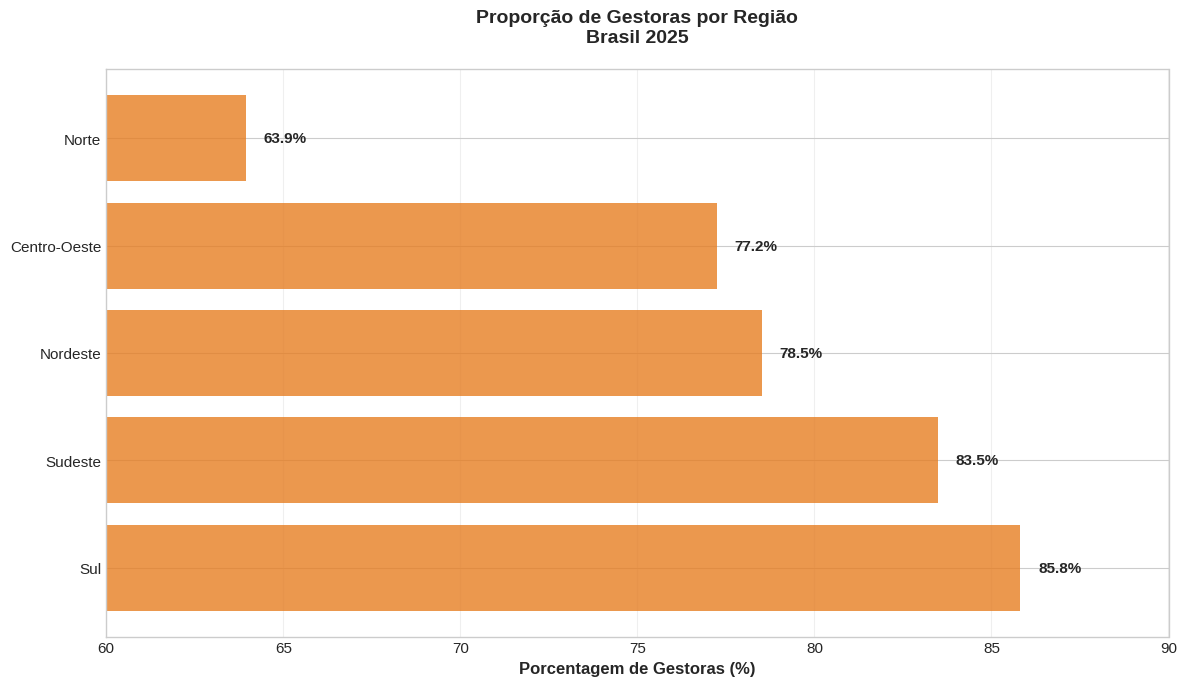

In [8]:
# Gráfico regional
fig, ax = plt.subplots(figsize=(12, 7))

regioes = df_regiao.index.tolist()
y_pos = np.arange(len(regioes))

bars = ax.barh(y_pos, df_regiao['% Gestoras'],
           color=[CORES['feminino'] if x >= 50 else CORES['neutro']
                  for x in df_regiao['% Gestoras']], alpha=0.8)

ax.axvline(x=50, color=CORES['masculino'], linestyle='--', linewidth=2, alpha=0.5)

ax.set_xlabel('Porcentagem de Gestoras (%)', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Gestoras por Região\nBrasil 2025',
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(regioes)
ax.set_xlim(60, 90)
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, pct) in enumerate(zip(bars, df_regiao['% Gestoras'])):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '06_gestoras_por_regiao.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 06_gestoras_por_regiao.png")
plt.show()

## 5️⃣ Análise Urbano vs Rural

In [9]:
# Comparar urbano vs rural
print("📊 Proporção de Gestoras: Urbano vs Rural")
print("=" * 50)

df_local = df.groupby('TP_LOCALIZACAO')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_local['Total'] = df_local['QT_GEST_BAS_FEM'] + df_local['QT_GEST_BAS_MASC']
df_local['% Gestoras'] = (df_local['QT_GEST_BAS_FEM'] / df_local['Total']) * 100

print(df_local[['Total', '% Gestoras']].to_string())

print("\n🔍 Insights:")
diferenca = abs(df_local.loc['Urbana', '% Gestoras'] - df_local.loc['Rural', '% Gestoras'])
print(f"   Diferença urbano/rural: {diferenca:.1f} pontos percentuais")

if diferenca < 2:
    print("   ✅ Não há diferença significativa entre urbano e rural")
else:
    print(f"   ⚠️ Há uma diferença de {diferenca:.1f} pp entre áreas urbanas e rurais")

📊 Proporção de Gestoras: Urbano vs Rural
                 Total  % Gestoras
TP_LOCALIZACAO                    
Rural            52508   71.415784
Urbana          138133   82.609514

🔍 Insights:
   Diferença urbano/rural: 11.2 pontos percentuais
   ⚠️ Há uma diferença de 11.2 pp entre áreas urbanas e rurais


## 6️⃣ Comparação: Alunas vs Gestoras

In [10]:
# Comparar proporção de alunas vs gestoras
print("📊 Comparação: Alunas vs Gestoras")
print("=" * 50)

# Calcular percentagens nacionais
pct_meninas_alunas = (df['QT_MAT_BAS_FEM'].sum() / (df['QT_MAT_BAS_FEM'].sum() + df['QT_MAT_BAS_MASC'].sum())) * 100
pct_gestoras = (df['QT_GEST_BAS_FEM'].sum() / (df['QT_GEST_BAS_FEM'].sum() + df['QT_GEST_BAS_MASC'].sum())) * 100

print(f"\n👩 Meninas nas salas de aula: {pct_meninas_alunas:.1f}%")
print(f"👩‍💼 Mulheres na gestão escolar: {pct_gestoras:.1f}%")

diferenca = pct_gestoras - pct_meninas_alunas
print(f"\n📊 Diferença: {diferenca:.1f} pontos percentuais")

if pct_gestoras > pct_meninas_alunas:
    print("\n✨ DESCOBERTA CHAVE:")
    print("   As mulheres estão PROPORCIONALMENTE MAIS REPRESENTADAS")
    print("   na gestão escolar do que nas salas de aula!")
    print(f"   {pct_gestoras:.1f}% dos gestores são mulheres vs {pct_meninas_alunas:.1f}% das alunas")

📊 Comparação: Alunas vs Gestoras

👩 Meninas nas salas de aula: 49.4%
👩‍💼 Mulheres na gestão escolar: 79.5%

📊 Diferença: 30.1 pontos percentuais

✨ DESCOBERTA CHAVE:
   As mulheres estão PROPORCIONALMENTE MAIS REPRESENTADAS
   na gestão escolar do que nas salas de aula!
   79.5% dos gestores são mulheres vs 49.4% das alunas


## ✅ Resumo do Notebook

### 📊 Análises Realizadas:
- ✅ Distribuição de gênero dos gestores
- ✅ Proporção de gestoras por rede de ensino
- ✅ Disparidades regionais na gestão
- ✅ Análise urbano vs rural
- ✅ Comparação: alunas vs gestoras

### 📁 Gráficos Gerados:
- `04_genero_gestores.png`
- `05_gestoras_por_rede.png`
- `06_gestoras_por_regiao.png`
- `07_alunas_vs_gestoras.png`

### 🔍 Insights Principais:
- **MULHERES SÃO MAIORIA na gestão escolar (79.5%)**
- Isso contraria a narrativa do "teto de vidro"
- Mulheres estão mais representadas na gestão que nas salas de aula

### 🚀 Próximos Passos:
Ir para **04_sintese_e_visualizacoes.ipynb**

---

✨ **Notebook 03 concluído!** ✨